# DQN with Acrobot-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `Acrobot-v1` using the Gymnassium API for envrionment.

Acrobot has a `Box(6,)` **observation space** and a `Discrete(3)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [ ]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from utils.device import resolve_device
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra, row_rank_property_check

## Reading the `config` file

In [ ]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = resolve_device(dev)
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

## Creating the Envrionment

In [ ]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
    clip=env_cfg["clip"],
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

## Creating the Agent

In [ ]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
    gd_steps_ceil=a["gd_steps_ceil"],
)

## Analysis (Low Rank)

In [ ]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs, outputs}. Resolve `name` to its callable,
# pre-bind config-supplied `kwargs` with functools.partial, and pair it with the
# list of output names so the training loop knows how many matrices to expect.
analysis["methods"] = [
    (partial(analysis_methods[m["name"]], **m.get("kwargs", {})), m["outputs"]) # Lookup partial but it passes in the arguments mentioned in the config to the 
    # required functions automatically 
    for m in analysis["methods"]
]
analysis

## Agent Training 

  4%|▍         | 21/500 [00:45<11:10,  1.40s/it]

episode 20 avg_rewarg: -425.7


  6%|▌         | 31/500 [00:57<07:48,  1.00it/s]

episode 30 avg_rewarg: -298.2


  8%|▊         | 41/500 [01:06<07:35,  1.01it/s]

episode 40 avg_rewarg: -232.4


 10%|█         | 50/500 [01:13<06:05,  1.23it/s]

episode 50 avg_rewarg: -188.2
****************************Hankel Q****************************


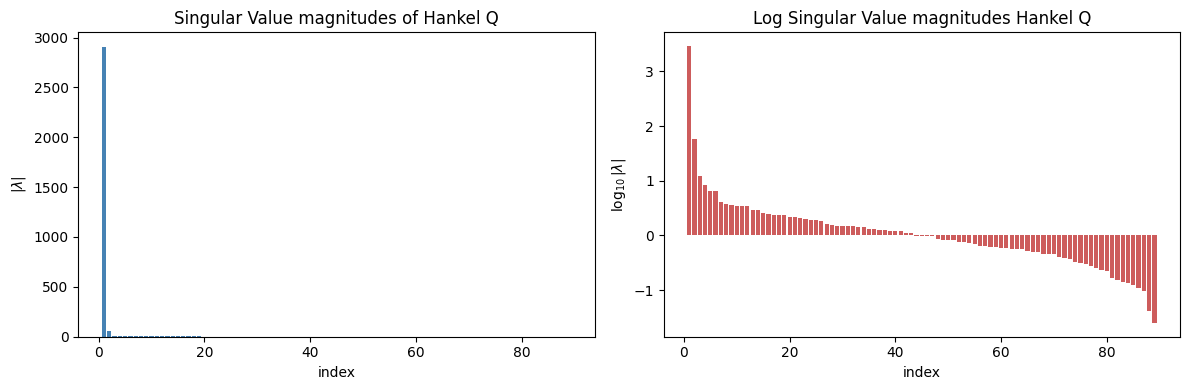

eff_rank: 1, stable_rank: 1.00, shape: (90, 89), non-zero rows :90, non-zero cols:89
top-r leverage spread: min=0.009769 max=0.01173 (uniform would be 0.01111)
row-space coherence score: 1.055
****************************Hankel V****************************


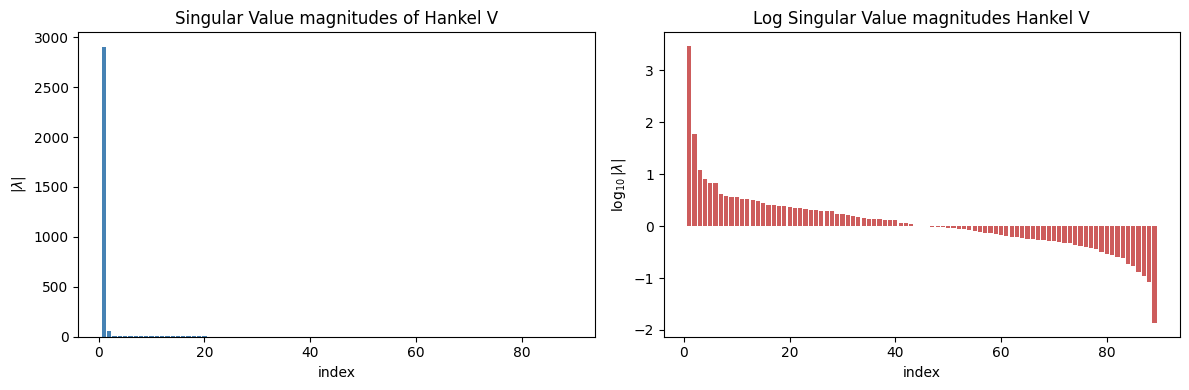

eff_rank: 1, stable_rank: 1.00, shape: (90, 89), non-zero rows :90, non-zero cols:89
top-r leverage spread: min=0.009758 max=0.01174 (uniform would be 0.01111)
row-space coherence score: 1.056
****************************Q-function****************************


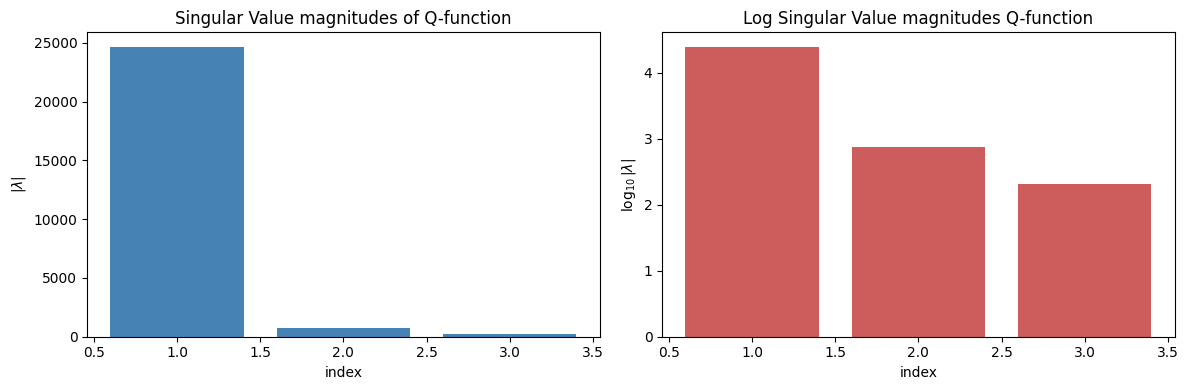

 10%|█         | 51/500 [01:18<15:22,  2.06s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=4.383e-16 max=1.269e-05 (uniform would be 3.815e-06)
row-space coherence score: 3.326


 12%|█▏        | 61/500 [01:25<04:41,  1.56it/s]

episode 60 avg_rewarg: -155.1


 14%|█▍        | 71/500 [01:31<04:14,  1.69it/s]

...

episode 80 avg_rewarg: -130.6


 18%|█▊        | 91/500 [01:42<04:00,  1.70it/s]

episode 90 avg_rewarg: -131.0


 20%|██        | 100/500 [01:48<03:56,  1.69it/s]

episode 100 avg_rewarg: -142.5
****************************Hankel Q****************************


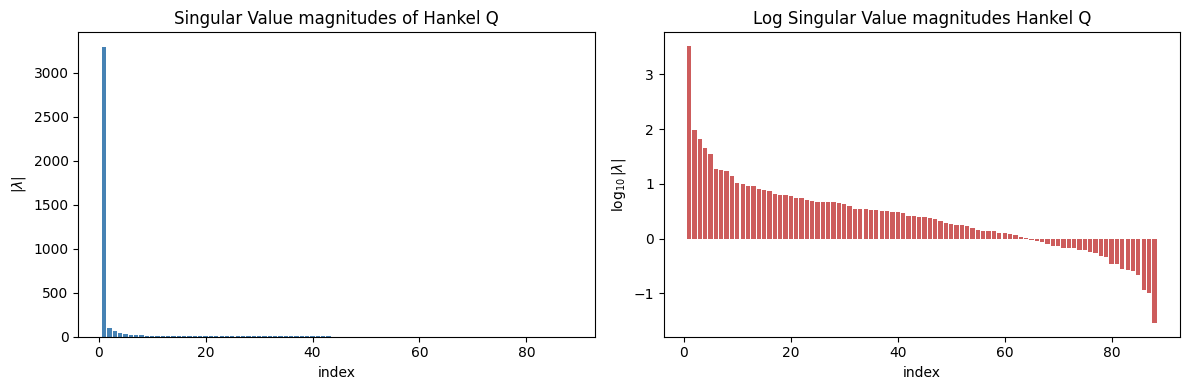

eff_rank: 1, stable_rank: 1.00, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: min=0.009827 max=0.01365 (uniform would be 0.01136)
row-space coherence score: 1.201
****************************Hankel V****************************


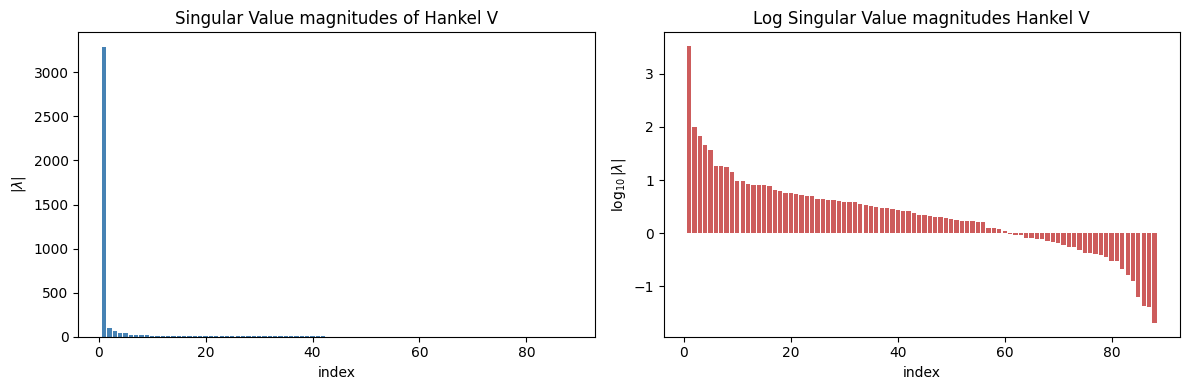

eff_rank: 1, stable_rank: 1.00, shape: (88, 88), non-zero rows :88, non-zero cols:88
top-r leverage spread: min=0.009814 max=0.01366 (uniform would be 0.01136)
row-space coherence score: 1.202
****************************Q-function****************************


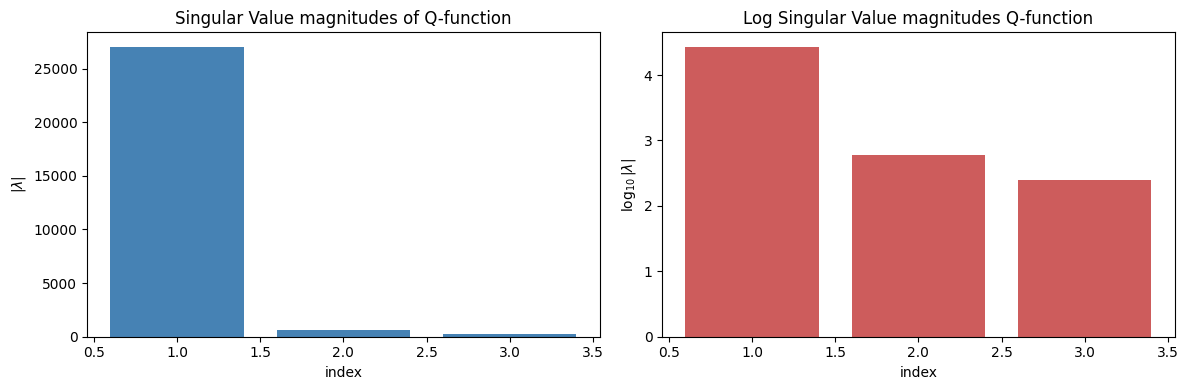

 20%|██        | 101/500 [01:53<12:42,  1.91s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=8.153e-17 max=1.021e-05 (uniform would be 3.815e-06)
row-space coherence score: 2.677


 22%|██▏       | 111/500 [01:59<03:34,  1.81it/s]

episode 110 avg_rewarg: -129.5


 24%|██▍       | 121/500 [02:04<03:53,  1.62it/s]

...

episode 130 avg_rewarg: -111.4


 28%|██▊       | 141/500 [02:21<03:19,  1.80it/s]

episode 140 avg_rewarg: -113.3


 30%|███       | 150/500 [02:27<03:41,  1.58it/s]

episode 150 avg_rewarg: -135.5
****************************Hankel Q****************************


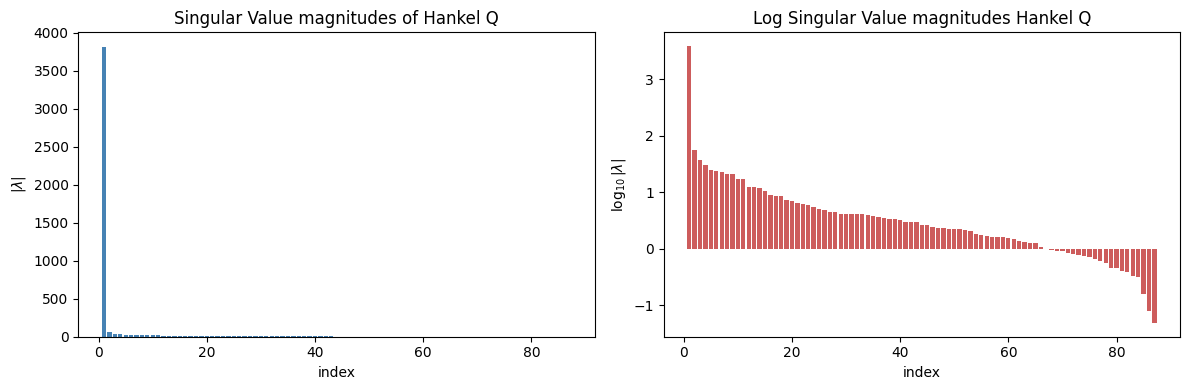

eff_rank: 1, stable_rank: 1.00, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: min=0.009447 max=0.01354 (uniform would be 0.01149)
row-space coherence score: 1.178
****************************Hankel V****************************


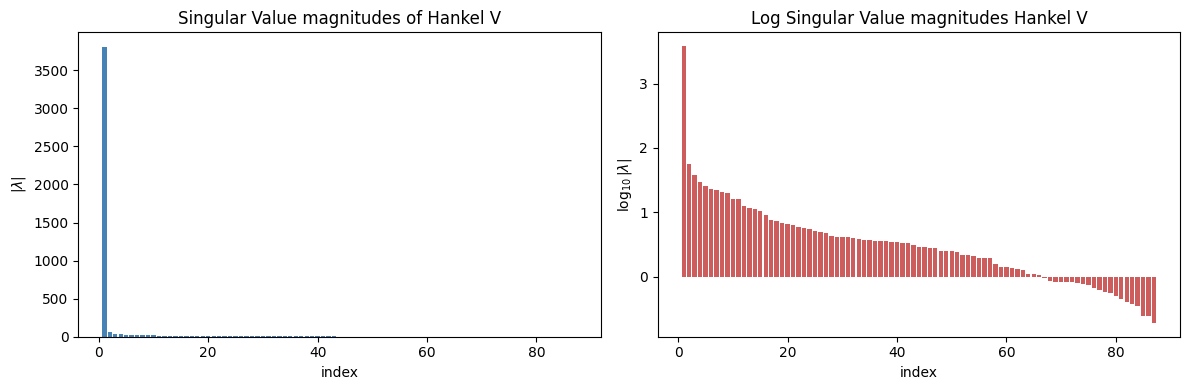

eff_rank: 1, stable_rank: 1.00, shape: (87, 87), non-zero rows :87, non-zero cols:87
top-r leverage spread: min=0.009456 max=0.01354 (uniform would be 0.01149)
row-space coherence score: 1.178
****************************Q-function****************************


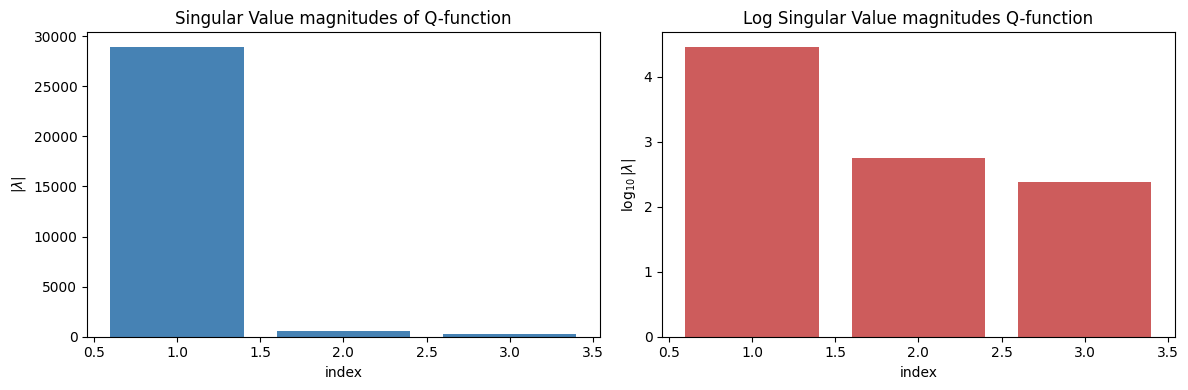

 30%|███       | 151/500 [02:42<29:36,  5.09s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.307e-14 max=9.867e-06 (uniform would be 3.815e-06)
row-space coherence score: 2.587


 32%|███▏      | 161/500 [02:50<04:37,  1.22it/s]

episode 160 avg_rewarg: -108.5


 34%|███▍      | 171/500 [03:01<05:18,  1.03it/s]

...

episode 180 avg_rewarg: -97.0


 38%|███▊      | 191/500 [03:17<03:56,  1.31it/s]

episode 190 avg_rewarg: -103.8


 40%|████      | 200/500 [03:23<02:40,  1.87it/s]

episode 200 avg_rewarg: -106.8
****************************Hankel Q****************************


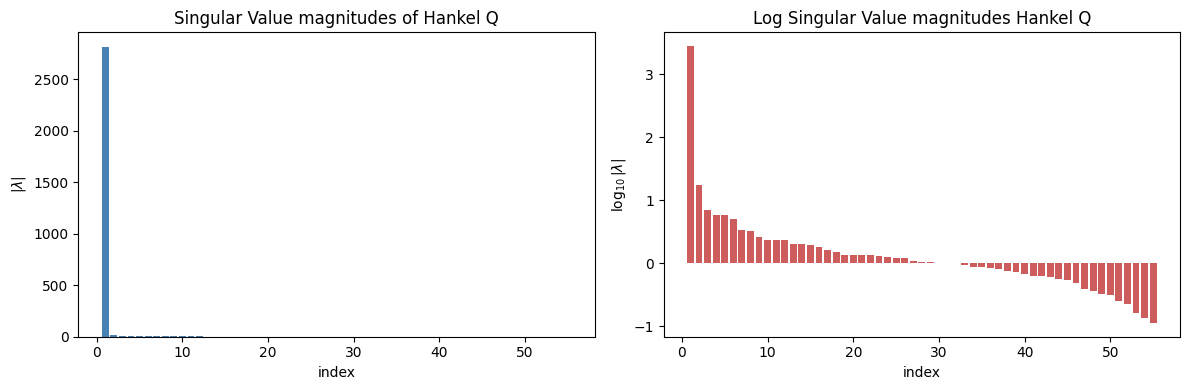

eff_rank: 1, stable_rank: 1.00, shape: (56, 55), non-zero rows :56, non-zero cols:55
top-r leverage spread: min=0.01532 max=0.02014 (uniform would be 0.01786)
row-space coherence score: 1.128
****************************Hankel V****************************


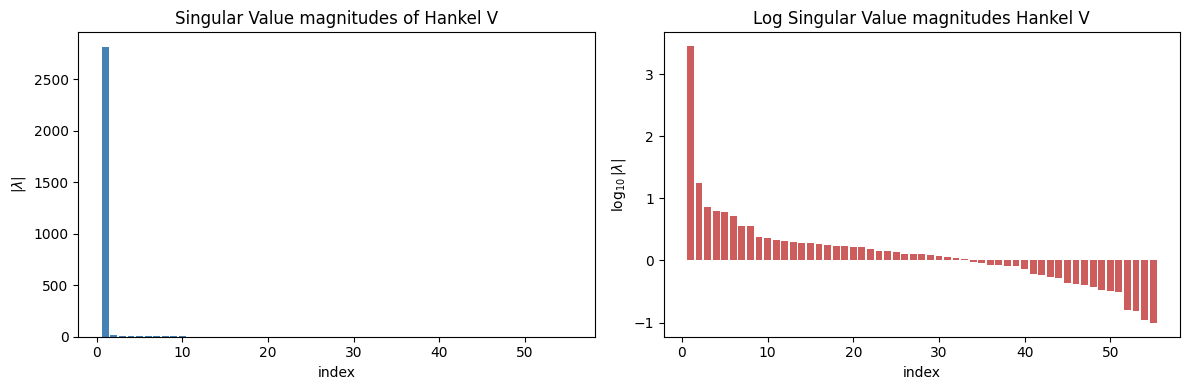

eff_rank: 1, stable_rank: 1.00, shape: (56, 55), non-zero rows :56, non-zero cols:55
top-r leverage spread: min=0.01531 max=0.02014 (uniform would be 0.01786)
row-space coherence score: 1.128
****************************Q-function****************************


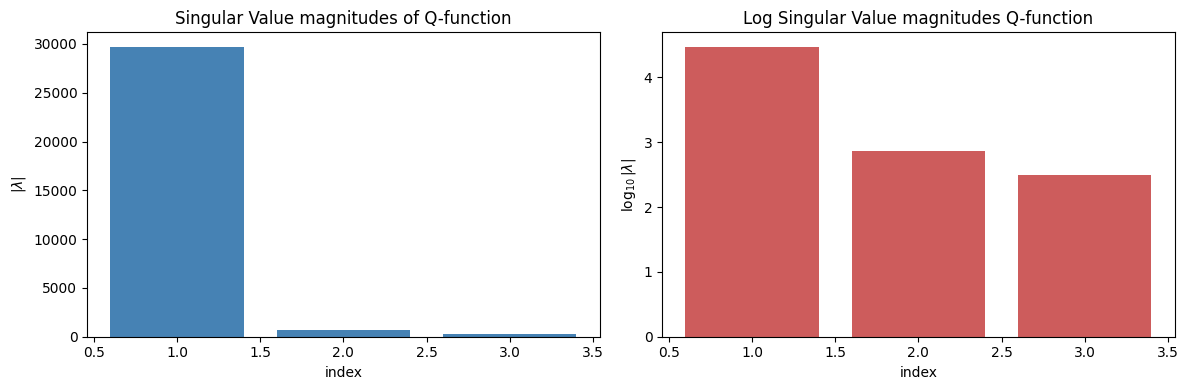

 40%|████      | 201/500 [03:28<09:11,  1.85s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=7.994e-15 max=1.133e-05 (uniform would be 3.815e-06)
row-space coherence score: 2.97


 42%|████▏     | 211/500 [03:34<02:50,  1.69it/s]

episode 210 avg_rewarg: -98.6


 44%|████▍     | 221/500 [03:39<02:24,  1.93it/s]

...

episode 230 avg_rewarg: -99.0


 48%|████▊     | 241/500 [03:50<02:26,  1.76it/s]

episode 240 avg_rewarg: -107.0


 50%|█████     | 250/500 [03:55<01:56,  2.15it/s]

episode 250 avg_rewarg: -132.3
****************************Hankel Q****************************


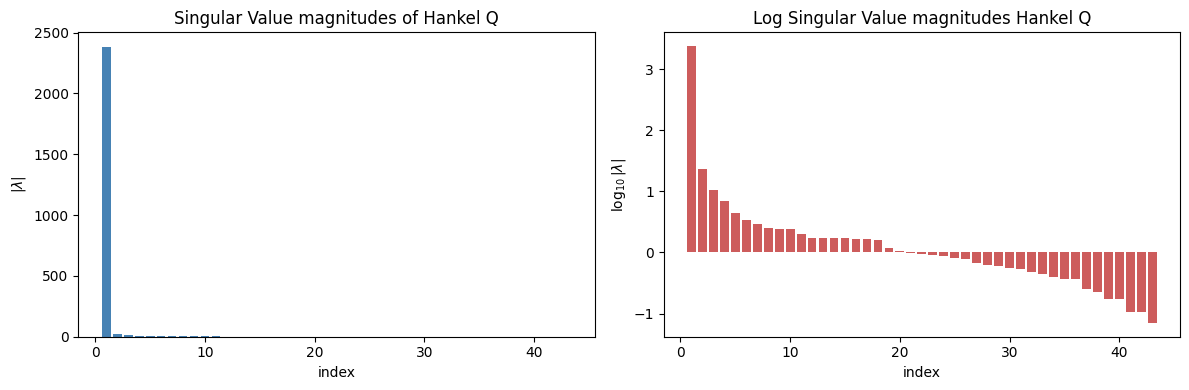

eff_rank: 1, stable_rank: 1.00, shape: (43, 43), non-zero rows :43, non-zero cols:43
top-r leverage spread: min=0.02028 max=0.02569 (uniform would be 0.02326)
row-space coherence score: 1.105
****************************Hankel V****************************


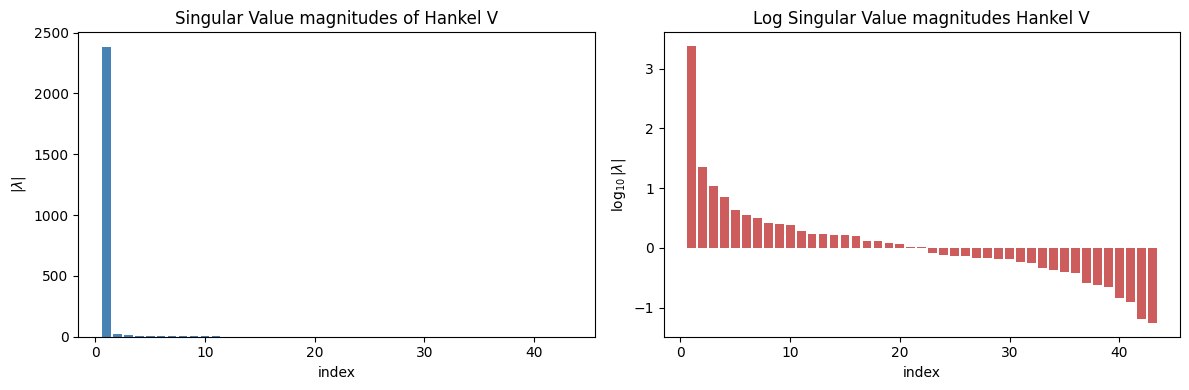

eff_rank: 1, stable_rank: 1.00, shape: (43, 43), non-zero rows :43, non-zero cols:43
top-r leverage spread: min=0.02028 max=0.02569 (uniform would be 0.02326)
row-space coherence score: 1.105
****************************Q-function****************************


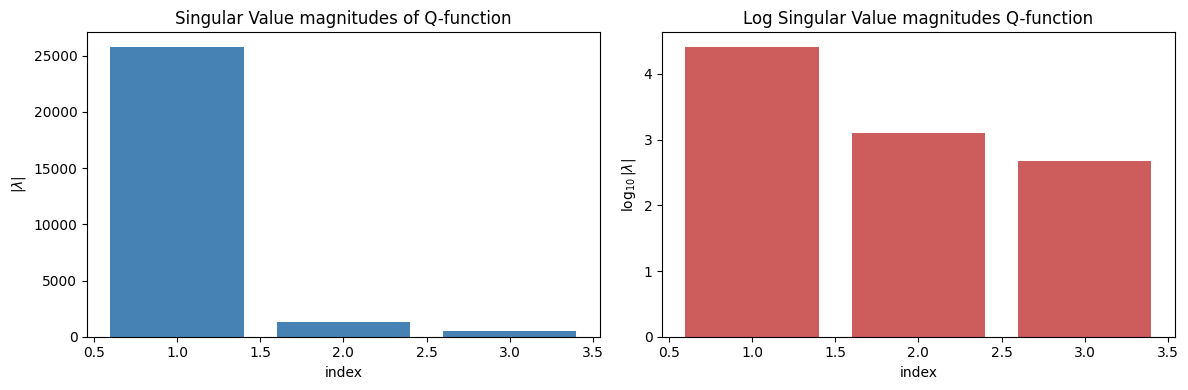

 50%|█████     | 251/500 [04:00<07:48,  1.88s/it]

eff_rank: 1, stable_rank: 1.00, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.437e-16 max=1.761e-05 (uniform would be 3.815e-06)
row-space coherence score: 4.616


 52%|█████▏    | 261/500 [04:05<01:52,  2.13it/s]

episode 260 avg_rewarg: -100.2


 54%|█████▍    | 271/500 [04:10<01:35,  2.41it/s]

...

episode 280 avg_rewarg: -134.5


 58%|█████▊    | 291/500 [04:21<01:43,  2.03it/s]

episode 290 avg_rewarg: -98.7


 60%|██████    | 300/500 [04:25<01:20,  2.48it/s]

episode 300 avg_rewarg: -87.6
****************************Hankel Q****************************


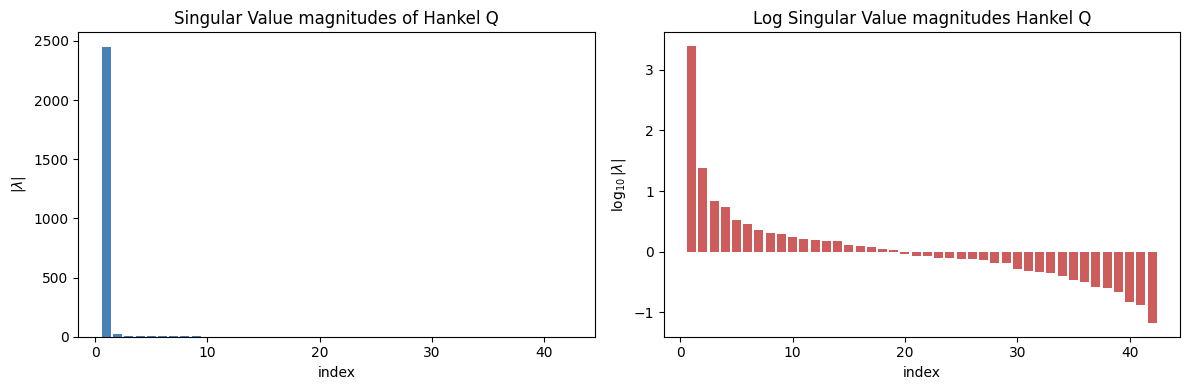

eff_rank: 1, stable_rank: 1.00, shape: (42, 42), non-zero rows :42, non-zero cols:42
top-r leverage spread: min=0.02026 max=0.02671 (uniform would be 0.02381)
row-space coherence score: 1.122
****************************Hankel V****************************


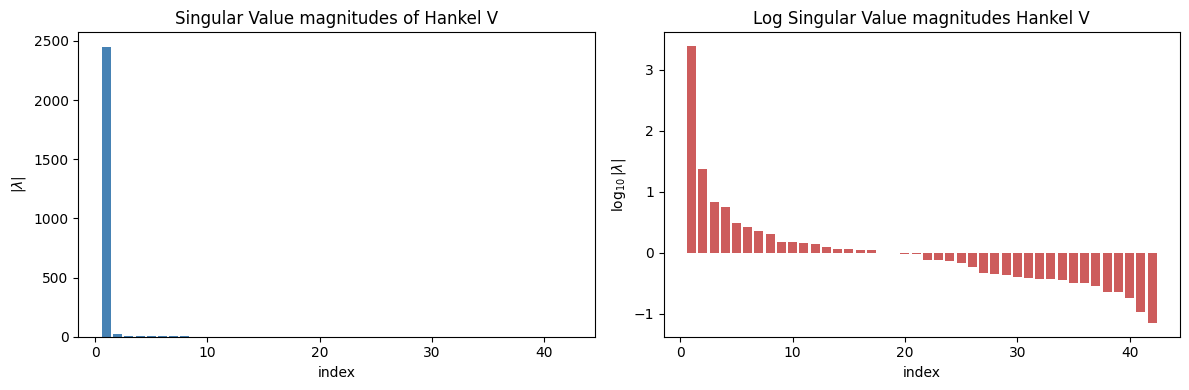

eff_rank: 1, stable_rank: 1.00, shape: (42, 42), non-zero rows :42, non-zero cols:42
top-r leverage spread: min=0.02026 max=0.02672 (uniform would be 0.02381)
row-space coherence score: 1.122
****************************Q-function****************************


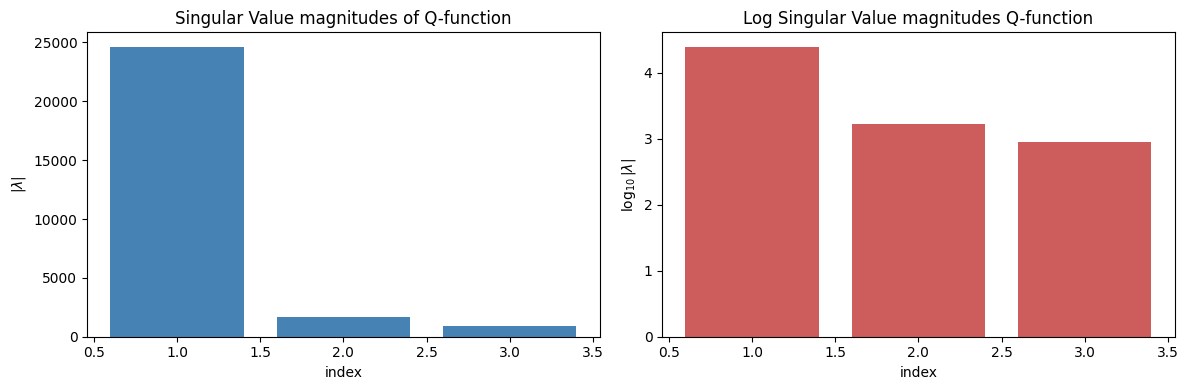

 60%|██████    | 301/500 [04:29<05:22,  1.62s/it]

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=4.48e-16 max=2.159e-05 (uniform would be 3.815e-06)
row-space coherence score: 5.66


 62%|██████▏   | 311/500 [04:36<01:42,  1.84it/s]

episode 310 avg_rewarg: -137.3


 64%|██████▍   | 321/500 [04:41<01:13,  2.43it/s]

...

episode 330 avg_rewarg: -105.2


 68%|██████▊   | 341/500 [04:50<01:17,  2.04it/s]

episode 340 avg_rewarg: -90.0


 70%|███████   | 350/500 [04:54<01:02,  2.39it/s]

episode 350 avg_rewarg: -88.4
****************************Hankel Q****************************


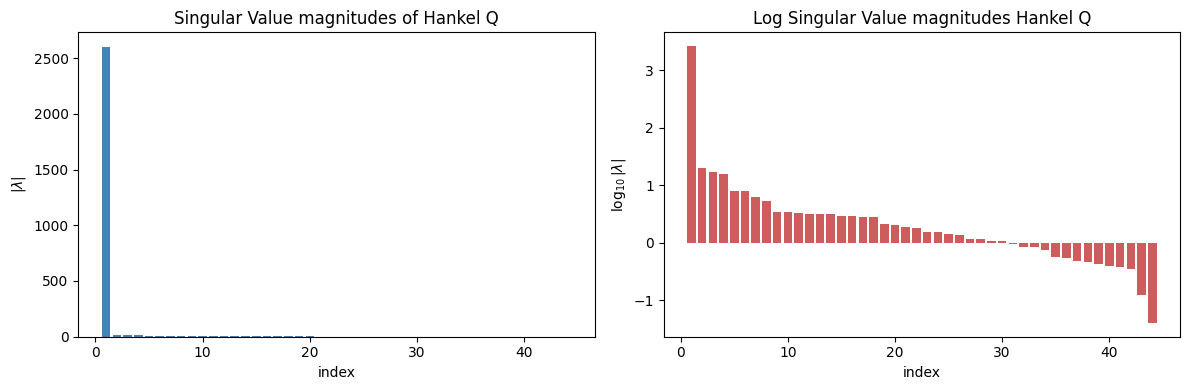

eff_rank: 1, stable_rank: 1.00, shape: (44, 44), non-zero rows :44, non-zero cols:44
top-r leverage spread: min=0.01891 max=0.02646 (uniform would be 0.02273)
row-space coherence score: 1.164
****************************Hankel V****************************


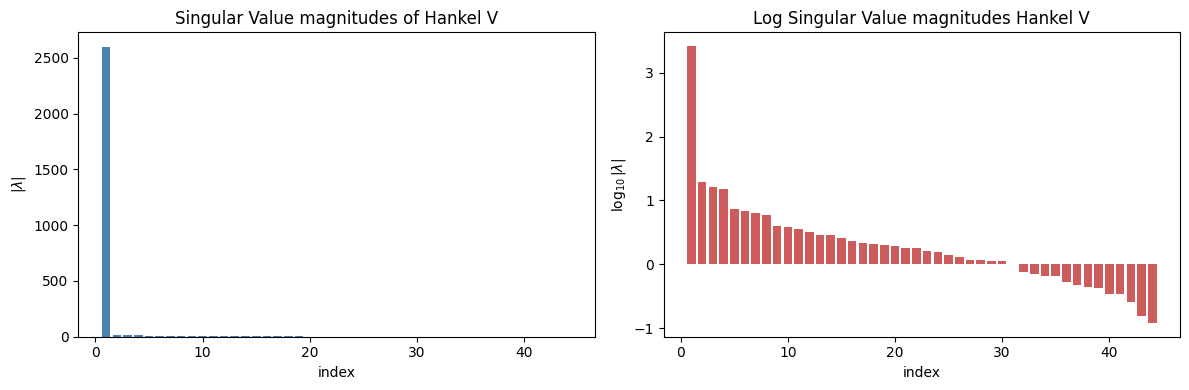

eff_rank: 1, stable_rank: 1.00, shape: (44, 44), non-zero rows :44, non-zero cols:44
top-r leverage spread: min=0.01889 max=0.02648 (uniform would be 0.02273)
row-space coherence score: 1.165
****************************Q-function****************************


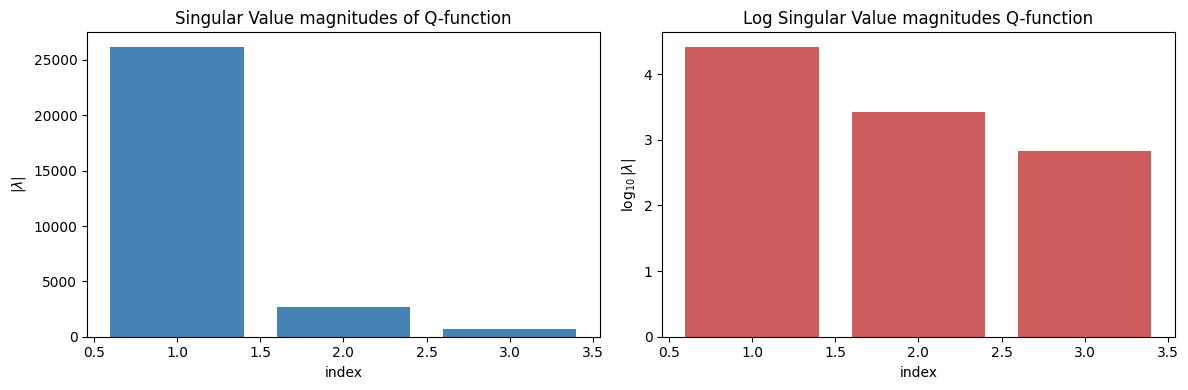

 70%|███████   | 351/500 [04:59<04:17,  1.73s/it]

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.143e-18 max=2.079e-05 (uniform would be 3.815e-06)
row-space coherence score: 5.45


 72%|███████▏  | 361/500 [05:03<01:02,  2.22it/s]

episode 360 avg_rewarg: -94.1


 74%|███████▍  | 371/500 [05:08<00:59,  2.19it/s]

...

episode 380 avg_rewarg: -91.7


 78%|███████▊  | 391/500 [05:17<00:51,  2.11it/s]

episode 390 avg_rewarg: -95.6


 80%|████████  | 400/500 [05:21<00:41,  2.41it/s]

episode 400 avg_rewarg: -86.9
****************************Hankel Q****************************


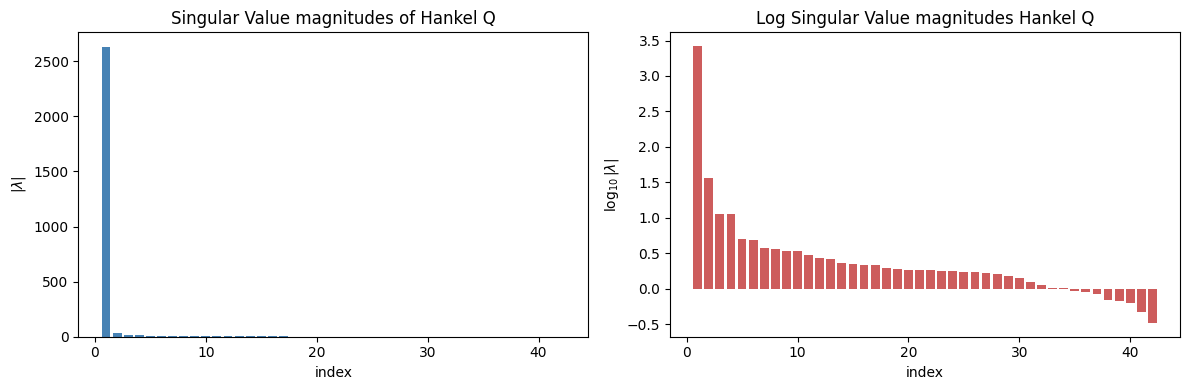

eff_rank: 1, stable_rank: 1.00, shape: (43, 42), non-zero rows :43, non-zero cols:42
top-r leverage spread: min=0.01915 max=0.02658 (uniform would be 0.02326)
row-space coherence score: 1.143
****************************Hankel V****************************


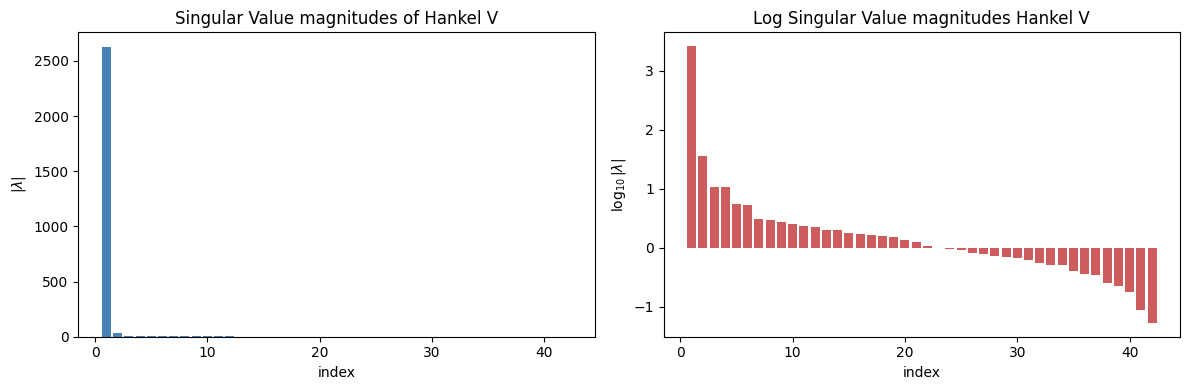

eff_rank: 1, stable_rank: 1.00, shape: (43, 42), non-zero rows :43, non-zero cols:42
top-r leverage spread: min=0.01915 max=0.02659 (uniform would be 0.02326)
row-space coherence score: 1.143
****************************Q-function****************************


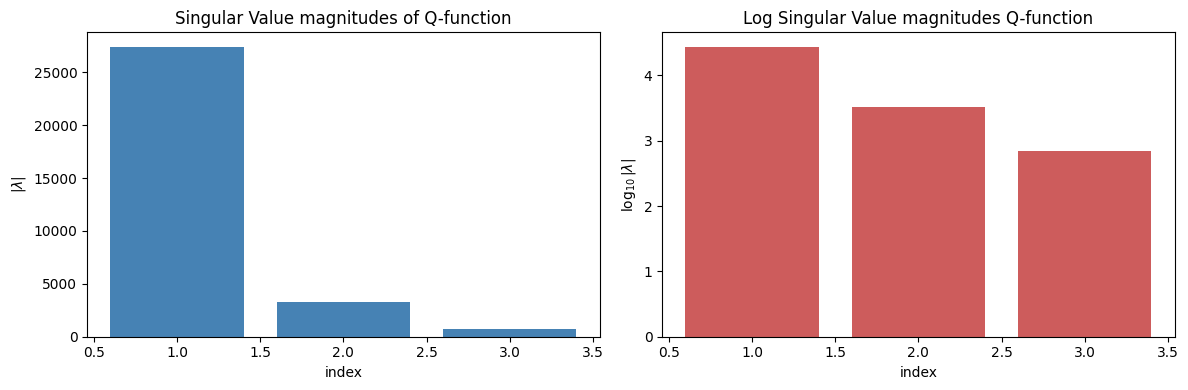

 80%|████████  | 401/500 [05:25<02:43,  1.65s/it]

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=4.413e-16 max=2.205e-05 (uniform would be 3.815e-06)
row-space coherence score: 5.779


 82%|████████▏ | 411/500 [05:30<00:44,  2.01it/s]

episode 410 avg_rewarg: -93.4


 84%|████████▍ | 421/500 [05:34<00:32,  2.47it/s]

...

episode 430 avg_rewarg: -93.4


 88%|████████▊ | 441/500 [05:44<00:27,  2.12it/s]

episode 440 avg_rewarg: -109.2


 90%|█████████ | 450/500 [05:48<00:21,  2.32it/s]

episode 450 avg_rewarg: -89.5
****************************Hankel Q****************************


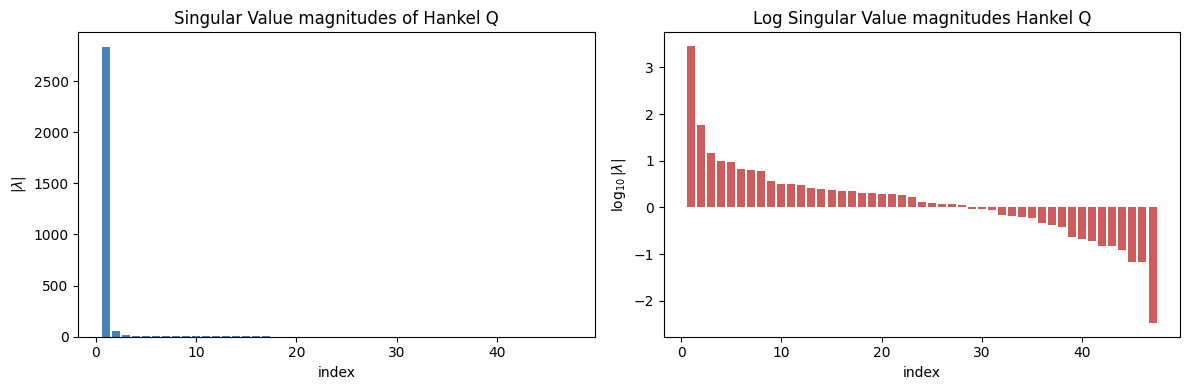

eff_rank: 1, stable_rank: 1.00, shape: (47, 47), non-zero rows :47, non-zero cols:47
top-r leverage spread: min=0.01537 max=0.02637 (uniform would be 0.02128)
row-space coherence score: 1.239
****************************Hankel V****************************


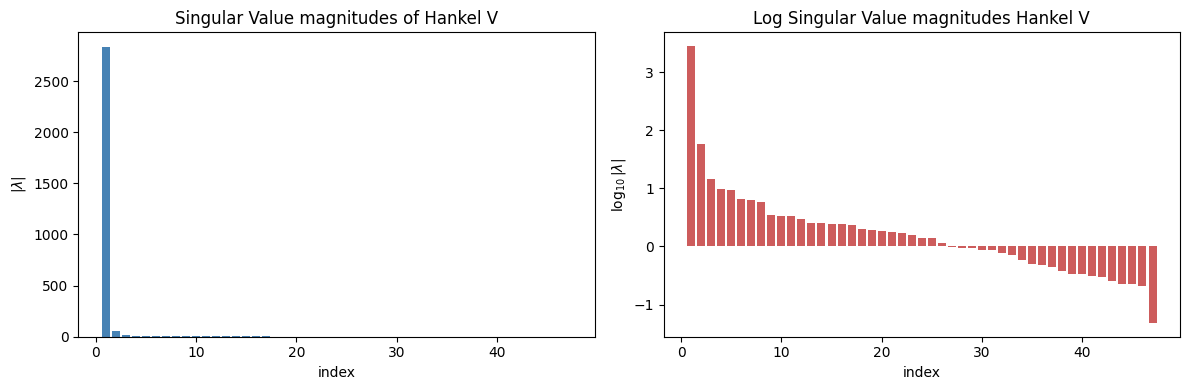

eff_rank: 1, stable_rank: 1.00, shape: (47, 47), non-zero rows :47, non-zero cols:47
top-r leverage spread: min=0.01538 max=0.02636 (uniform would be 0.02128)
row-space coherence score: 1.239
****************************Q-function****************************


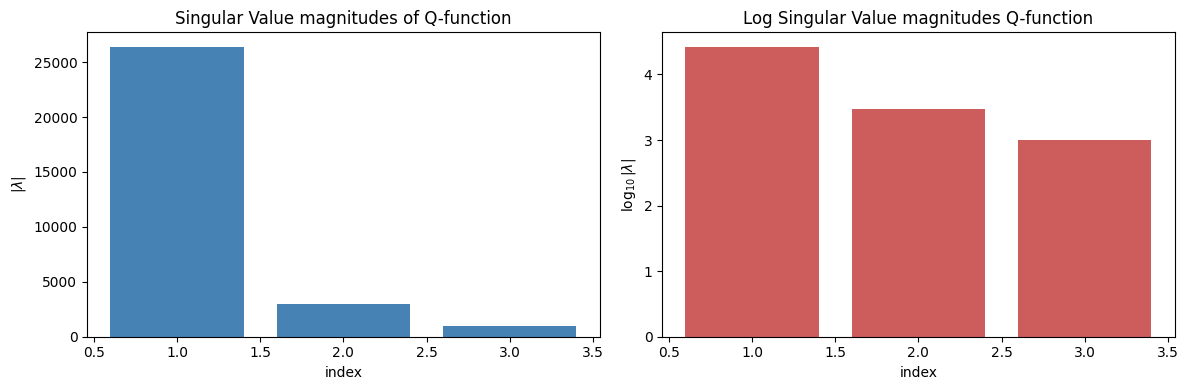

 90%|█████████ | 451/500 [05:53<01:26,  1.76s/it]

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=1.401e-17 max=4.853e-05 (uniform would be 3.815e-06)
row-space coherence score: 12.72


 92%|█████████▏| 461/500 [05:58<00:19,  1.97it/s]

episode 460 avg_rewarg: -89.5


 94%|█████████▍| 471/500 [06:02<00:12,  2.40it/s]

...

 96%|█████████▌| 481/500 [06:06<00:07,  2.38it/s]

episode 480 avg_rewarg: -85.0


 98%|█████████▊| 491/500 [06:10<00:03,  2.37it/s]

episode 490 avg_rewarg: -82.9


100%|██████████| 500/500 [06:14<00:00,  1.33it/s]


In [16]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    train_frequency_steps = t["train_frequency_steps"],
    np_seed=seed,
    analysis_config = analysis
)

## Training and Analysis Plots (now with pi*(theeta))

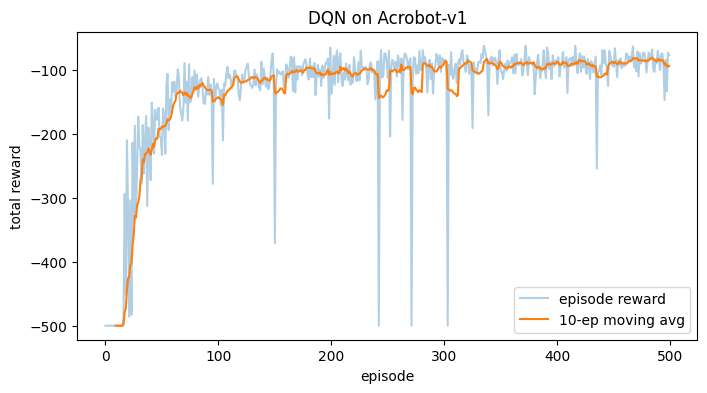

In [17]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend(); plt.show()

Hankel Q


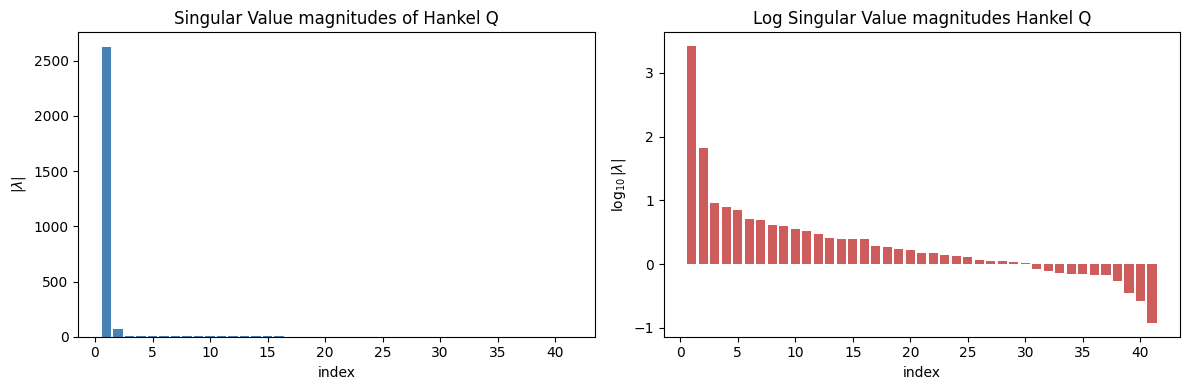

eff_rank: 1, stable_rank: 1.00, shape: (42, 41), non-zero rows :42, non-zero cols:41
top-r leverage spread: min=0.018 max=0.02831 (uniform would be 0.02381)
row-space coherence score: 1.189
Hankel V


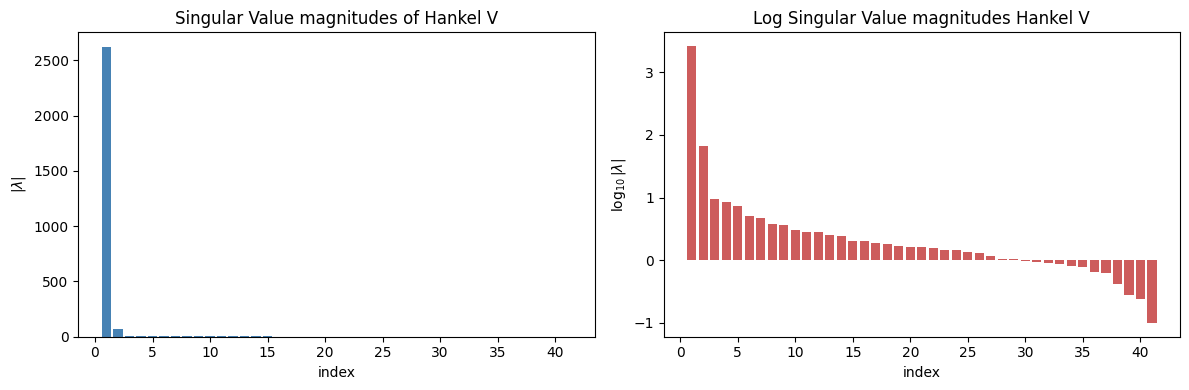

eff_rank: 1, stable_rank: 1.00, shape: (42, 41), non-zero rows :42, non-zero cols:41
top-r leverage spread: min=0.01801 max=0.02833 (uniform would be 0.02381)
row-space coherence score: 1.19
Q-function


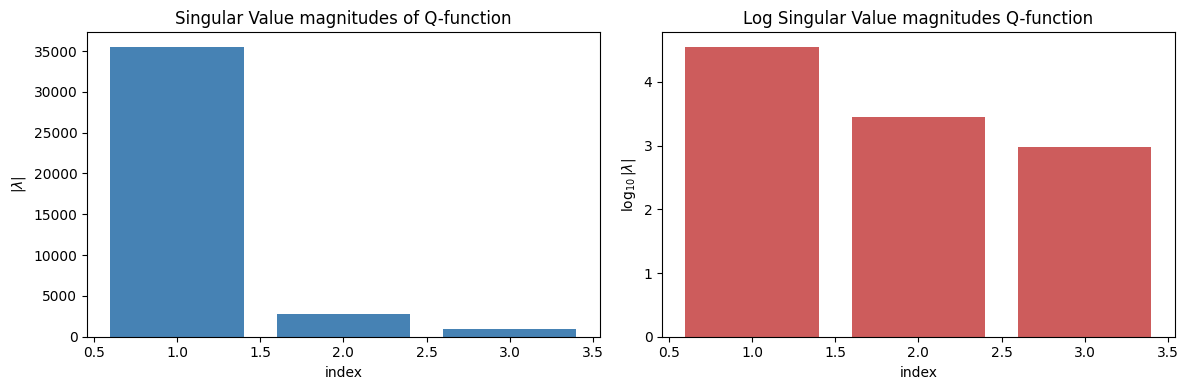

eff_rank: 1, stable_rank: 1.01, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: min=6.777e-16 max=3.658e-05 (uniform would be 3.815e-06)
row-space coherence score: 9.59


In [18]:
for method, names in analysis["methods"]:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        r, sr, shape, irs, rc, nzc, nzr = row_rank_property_check(matrix, name)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: min={irs.min():.4g} max={irs.max():.4g} (uniform would be {1.0/shape[0]:.4g})")
        print(f"row-space coherence score: {rc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained `agent` and display it inline. The eval env is rebuilt with `render_mode="rgb_array"` so frames can be captured.

In [ ]:
# Greedy rollout video of the trained agent
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = make_environment(
    env_cfg["name"],
    render_mode="rgb_array",
    discrete_config=env_cfg["discrete_config"],
    normalise=env_cfg["normalise"],
    clip=env_cfg["clip"],
)
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=seed)
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)